# Rokt holdout experiment analysis

**Business question:** Did showing Rokt advertisements create incremental conversion lift compared with a suppressed-ad holdout?

**Portfolio result:** Under the brief-defined unique-user KPI, treatment converted at **2.23%** versus **1.95%** for control: **+13.9% relative uplift**. A user-cohort sensitivity analysis estimates a smaller but still positive effect.

The raw dataset is private and excluded from this public repository. Every displayed result was generated from the sanitized pipeline in `src/analysis.py`.


## 1. Reproducible setup

Set `ROKT_DATA_PATH` to your authorized local copy of the CSV. The notebook never embeds raw user or session identifiers.


In [1]:
import os
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.analysis import (
    allocation_summary,
    cohort_summary,
    load_and_clean,
    overall_metrics,
    segment_summary,
    sensitivity_summary,
)

DATA_PATH = Path(os.environ.get("ROKT_DATA_PATH", PROJECT_ROOT / "data" / "raw" / "rokt_data.csv"))
if not DATA_PATH.exists():
    raise FileNotFoundError("Set ROKT_DATA_PATH to an authorized local copy of rokt_data.csv")


## 2. Data-quality audit and cleaning

The pipeline removes the invalid 203902 cohort and exact duplicate records, standardizes device labels, fills missing device/gender categories, creates the conversion flag, and parses timestamps. The audit also checks whether users or sessions appear in both experiment groups.


In [2]:
df, quality = load_and_clean(DATA_PATH)
quality


check,count,status
Raw rows,889091,Input
Invalid cohort rows removed,1,Removed
Exact duplicate rows removed,36893,Removed
Clean analysis rows,852197,Output
Missing device values filled,118,Repaired
Missing gender values filled,87065,Repaired
Unique users,671795,Context
Unique sessions,773656,Context
Users appearing in both groups across months,26426,Caution
User-cohort pairs appearing in both groups,92,Caution


The original notebook missed `NaN` device/gender values because it used `replace('')` rather than `fillna()`. It also retained exact duplicates, which inflated VPT and conversion-value totals. Both issues are corrected here.


## 3. Primary experiment KPIs


In [3]:
group_kpis, headline = overall_metrics(df)
group_kpis[['group', 'users', 'converted_users', 'conversion_rate', 'sessions', 'vpt_usd']]


group,users,converted_users,conversion_rate,sessions,vpt_usd
treatment,576471,12833,2.2261%,647057,$0.0763
control,121750,2379,1.9540%,126605,$0.0000


Treatment exceeded control by **0.272% percentage points**, equal to **13.9% relative uplift**. Under a simple counterfactual applying the control rate to treatment users, this corresponds to approximately **1,569 incremental conversions**.

VPT uses `bidprice_usd / unique sessions`, exactly as defined in the supplied brief.


## 4. Statistical confidence


In [4]:
print(f"Z-statistic: {headline['z_statistic']:.3f}")
print(f"P-value: {headline['p_value']:.3e}")
print(
    "95% CI, absolute lift: "
    f"[{headline['absolute_lift_ci_low']:.3%}, {headline['absolute_lift_ci_high']:.3%}]"
)
print(
    "95% CI, relative uplift: "
    f"[{headline['relative_uplift_ci_low']:.1%}, {headline['relative_uplift_ci_high']:.1%}]"
)


Z-statistic: 5.910
P-value: 3.422e-09
95% CI, absolute lift: [0.186%, 0.359%]
95% CI, relative uplift: [9.1%, 19.0%]


This conventional test follows the requested user-level KPI. Because some users change assignment across months, the independence assumption is imperfect; the sensitivity analysis below is part of the conclusion, not a footnote to ignore.


## 5. Performance by cohort


In [5]:
cohorts = cohort_summary(df)
cohorts[['cohort_label', 'treatment_cr', 'control_cr', 'relative_uplift', 'p_value']]


cohort_label,treatment_cr,control_cr,relative_uplift,p_value
Feb 2020,3.00%,2.35%,27.58%,2.4e-08
Mar 2020,2.94%,2.31%,27.12%,6.74e-07
Apr 2020,2.10%,1.88%,11.58%,0.019
May 2020,1.82%,1.56%,16.30%,0.0126
Jun 2020,1.53%,1.21%,26.55%,5.65e-05


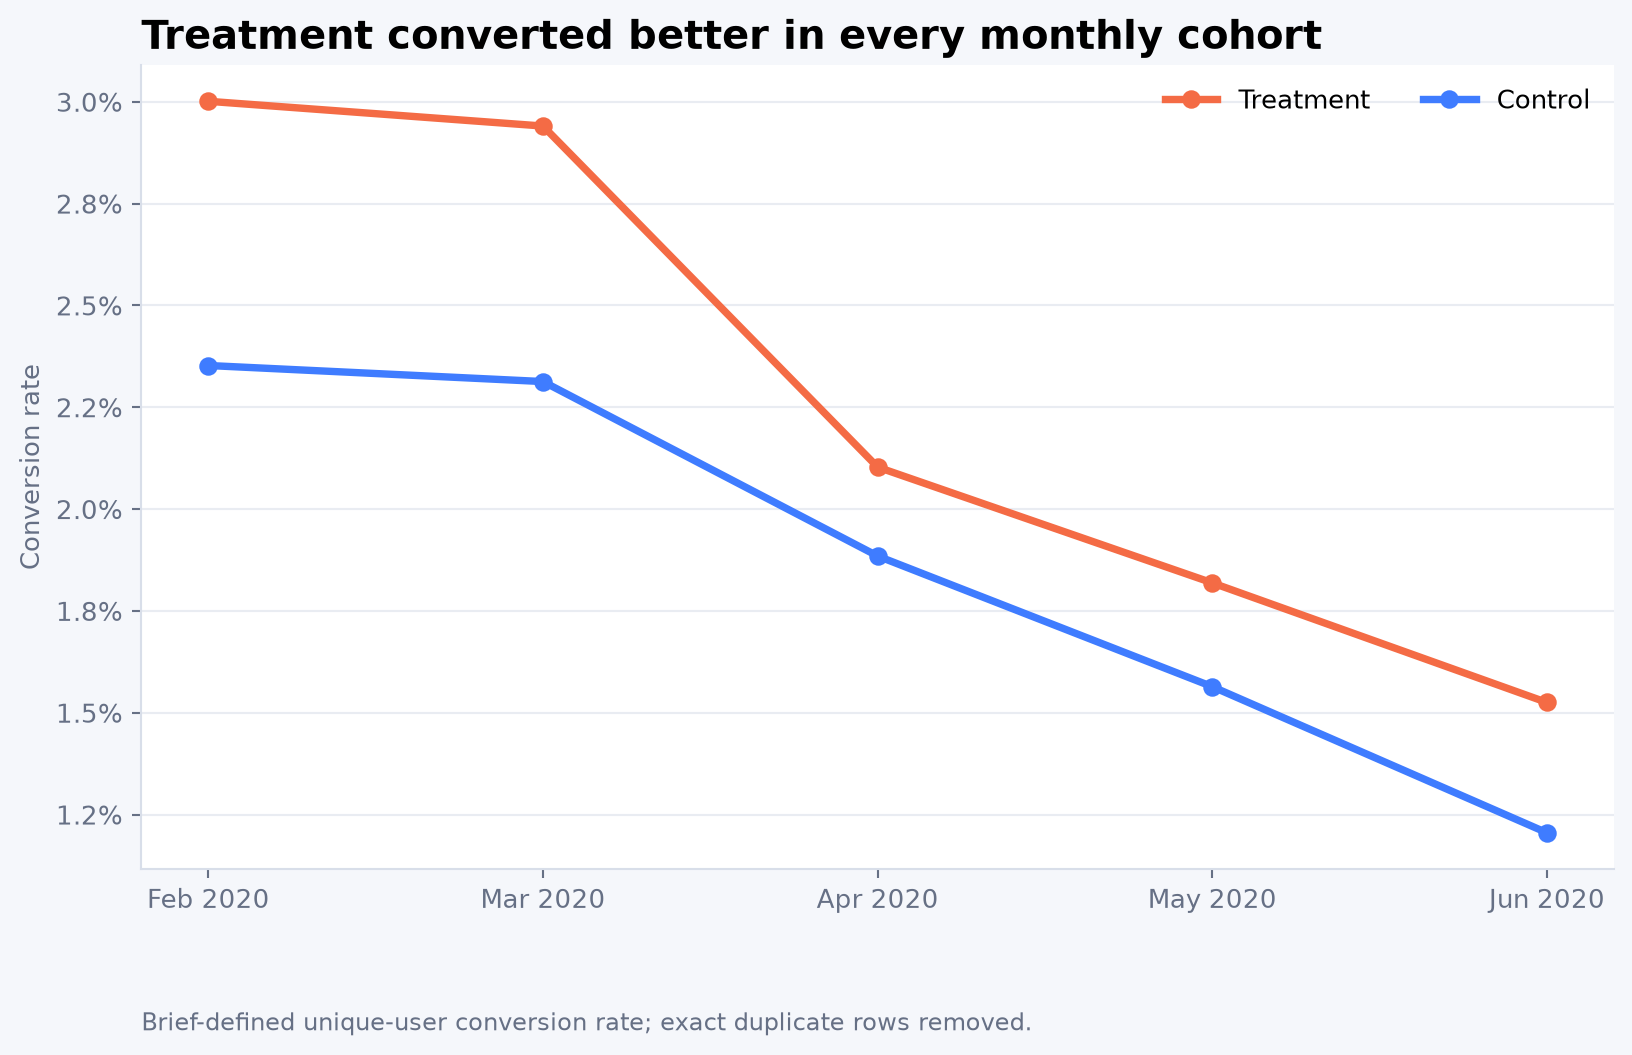

In [6]:
from IPython.display import Image, display
display(Image(filename=PROJECT_ROOT / "images" / "cohort_conversion_rates.png"))


Treatment conversion exceeded control in every monthly cohort. Both groups declined materially from February to June, which signals a strong time effect alongside the treatment-control gap.


## 6. Unit-of-analysis sensitivity


In [7]:
sensitivity = sensitivity_summary(df)
sensitivity[['analysis_unit', 'treatment_cr', 'control_cr', 'relative_uplift', 'p_value']]


analysis_unit,treatment_cr,control_cr,relative_uplift,p_value
Brief-defined unique users,2.23%,1.95%,13.93%,3.42e-09
User-cohort,1.99%,1.89%,5.46%,0.0162
Session,1.98%,1.88%,5.57%,0.0142


The brief-defined result is the required KPI, but its magnitude is sensitive to the unit chosen. User-cohort and session views both produce approximately **+5.5% uplift** and remain statistically significant. The correct causal estimate ultimately depends on confirmation of the randomization unit.


## 7. Descriptive device segmentation


In [8]:
devices = segment_summary(df, "device")
devices[['device', 'treatment_users', 'control_users', 'treatment_cr', 'control_cr', 'relative_uplift']]


device,treatment_users,control_users,treatment_cr,control_cr,relative_uplift
Desktop,110190,27279,3.09%,2.39%,29.14%
Mobile,388456,76162,1.94%,1.82%,6.43%
Other,22406,7981,2.33%,1.87%,24.55%
Tablet,67480,11350,2.07%,1.70%,21.49%
Unknown,88,23,1.14%,0.00%,nan%


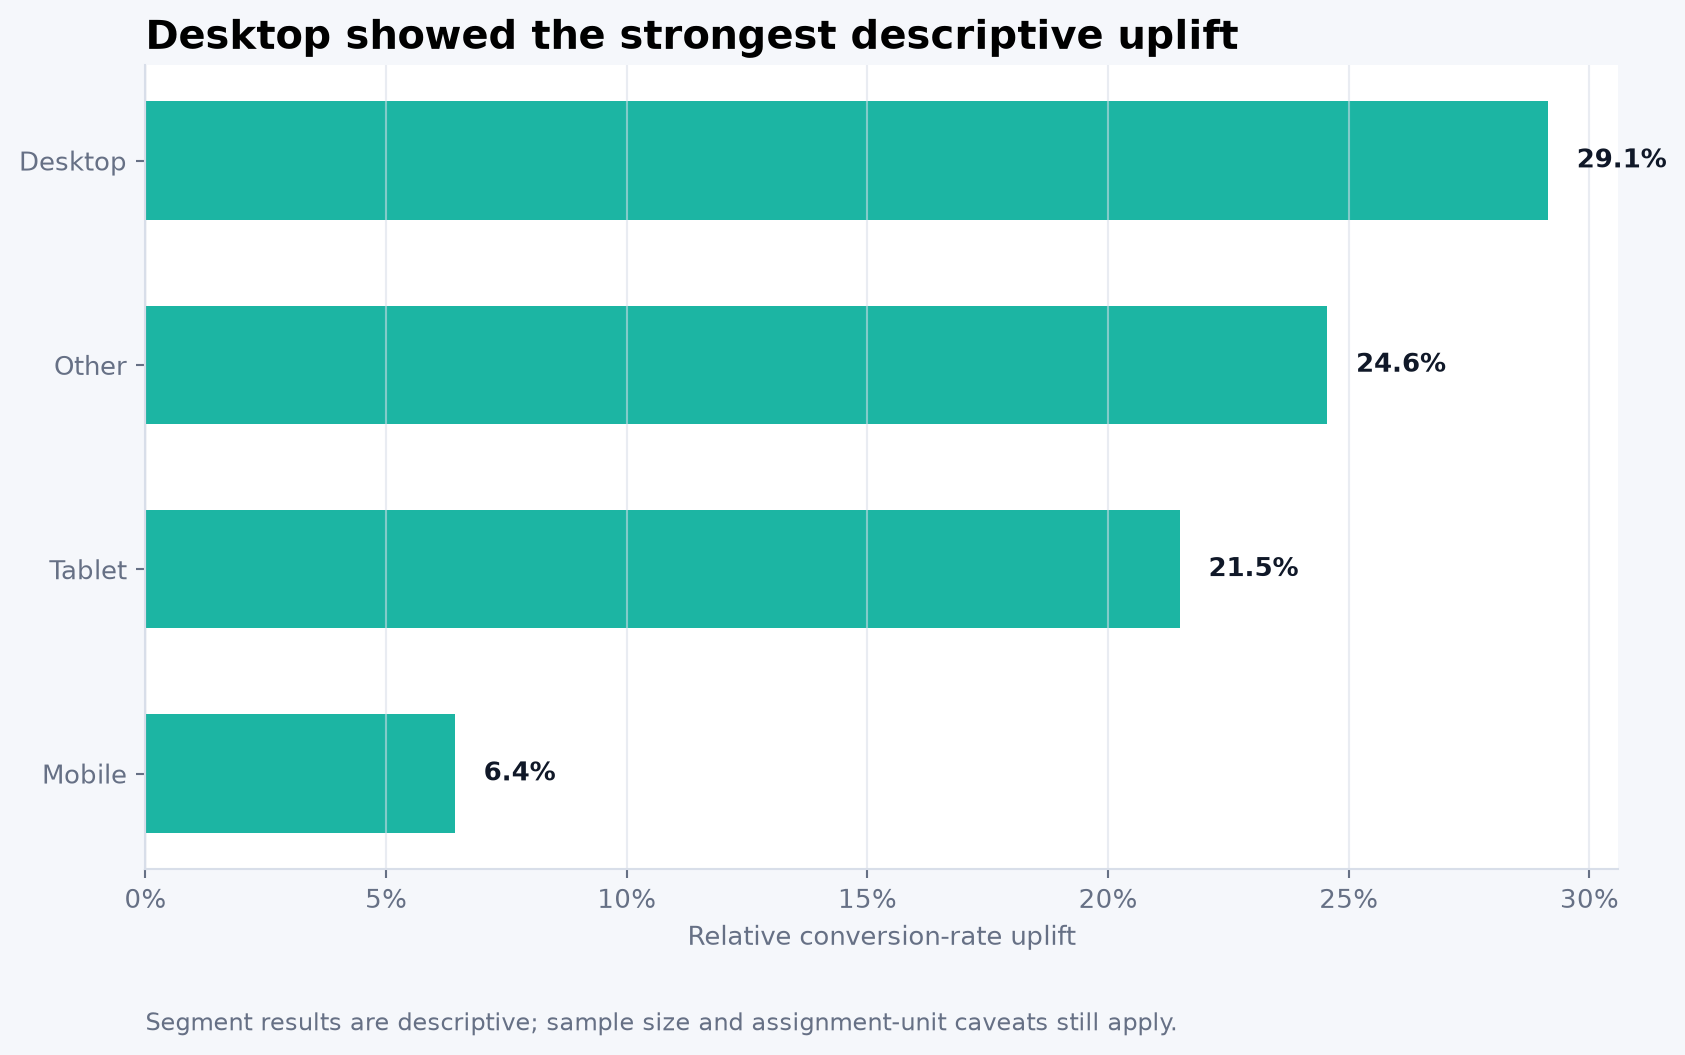

In [9]:
display(Image(filename=PROJECT_ROOT / "images" / "device_uplift.png"))


Desktop shows the strongest descriptive uplift, while Mobile shows the weakest. These are exploratory segment findings rather than proof that device causes different treatment effects.


## 8. Business interpretation

- Under the brief-defined KPI, the treatment generated **+13.9% relative conversion uplift**.
- The effect was positive in all five cohorts, but overall conversion declined over time in both arms.
- A more conservative user-cohort view estimates about **+5.5% uplift**, so the randomization unit should be confirmed before rollout or financial forecasting.
- The simple counterfactual estimates **1,569 additional conversions**.
- The corresponding **$239,887** is an estimated incremental conversion value under an equal-average-value assumption, not verified Rokt revenue.

### Recommendation

Treat the result as a positive experiment signal. Validate assignment logic, then prioritize follow-up analysis on cohort decline and device differences before using the estimate for investment decisions.


## 9. Limitations

- The supplied brief does not explicitly identify the randomization unit.
- Users can reappear and change groups across months.
- Segment comparisons are descriptive and are not adjusted for multiple testing.
- `value` is conversion value attributed to an event; it should not be labeled company revenue without a business definition.
- The public portfolio excludes raw data, pseudonymous user/session identifiers, and the proprietary assignment screenshots.
